In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np


print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")

# Define custom VGG16-based model
class VGG16DeepFake(nn.Module):
    def __init__(self):
        super(VGG16DeepFake, self).__init__()


        self.vgg16 = models.vgg16(pretrained=True)


        for param in self.vgg16.parameters():
            param.requires_grad = False


        self.vgg16.classifier = nn.Sequential(
            nn.Linear(25088, 512),  # 512 * 7 * 7 = 25088
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.vgg16(x)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG16DeepFake().to(device)


print(model)


PyTorch version: 2.6.0+cu124
NumPy version: 2.0.2


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 130MB/s]


VGG16DeepFake(
  (vgg16): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


train_dir = "./archive/real_vs_fake/real-vs-fake/train"
test_dir = "./archive/real_vs_fake/real-vs-fake/test"


train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = ImageFolder(train_dir, transform=train_transforms)
test_dataset = ImageFolder(test_dir, transform=test_transforms)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 100000
Test samples: 20000


In [ ]:
import torch.optim as optim
import torch.nn as nn


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


num_epochs = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


train_losses, val_losses = [], []
train_accs, val_accs = [], []


for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.float().to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(test_dataset)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Save model
torch.save(model.state_dict(), "./model.pth")

Using device: cuda
Epoch 1/15, Train Loss: 0.4420, Train Acc: 0.7970, Val Loss: 0.3210, Val Acc: 0.8648
Epoch 2/15, Train Loss: 0.3671, Train Acc: 0.8388, Val Loss: 0.2921, Val Acc: 0.8813
Epoch 3/15, Train Loss: 0.3355, Train Acc: 0.8558, Val Loss: 0.2701, Val Acc: 0.8923
Epoch 4/15, Train Loss: 0.3172, Train Acc: 0.8656, Val Loss: 0.2548, Val Acc: 0.8962
Epoch 5/15, Train Loss: 0.3030, Train Acc: 0.8726, Val Loss: 0.2551, Val Acc: 0.8995
Epoch 6/15, Train Loss: 0.2873, Train Acc: 0.8797, Val Loss: 0.2437, Val Acc: 0.9020
Epoch 7/15, Train Loss: 0.2813, Train Acc: 0.8831, Val Loss: 0.2349, Val Acc: 0.9092
Epoch 8/15, Train Loss: 0.2716, Train Acc: 0.8878, Val Loss: 0.2543, Val Acc: 0.9016
Epoch 9/15, Train Loss: 0.2623, Train Acc: 0.8925, Val Loss: 0.2360, Val Acc: 0.9099
Epoch 10/15, Train Loss: 0.2569, Train Acc: 0.8938, Val Loss: 0.2219, Val Acc: 0.9163
Epoch 11/15, Train Loss: 0.2513, Train Acc: 0.8967, Val Loss: 0.2238, Val Acc: 0.9177
Epoch 12/15, Train Loss: 0.2448, Train Acc: 

In [ ]:
import matplotlib.pyplot as plt

def plot_loss(epochs, loss, val_loss):
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_accuracy(epochs, acc, val_acc):
    plt.plot(epochs, acc, label="Training Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

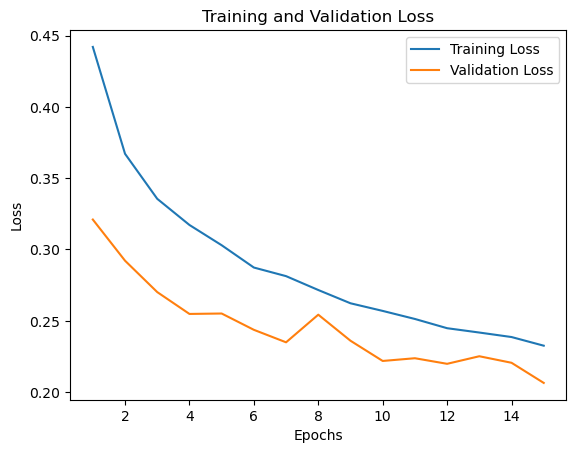

In [ ]:
plot_loss(range(1, len(train_losses) + 1), train_losses, val_losses)

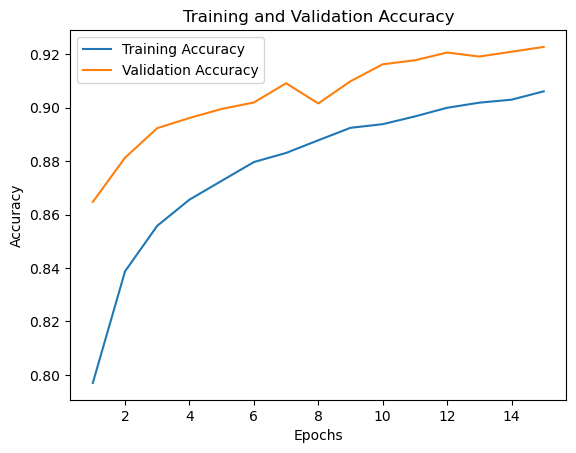

In [ ]:
plot_accuracy(range(1, len(train_accs) + 1), train_accs, val_accs)

In [ ]:
from sklearn import metrics
import numpy as np


model.eval()
y_pred, y_test = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs).squeeze().cpu().numpy()
        y_pred.extend(outputs)
        y_test.extend(labels.numpy())

y_pred = np.array(y_pred)
y_test = np.array(y_test)


print("ROC-AUC Score:", metrics.roc_auc_score(y_test, y_pred))
print("AP Score:", metrics.average_precision_score(y_test, y_pred))
print()
print(metrics.classification_report(y_test, y_pred > 0.5))

ROC-AUC Score: 0.975928695
AP Score: 0.9757131332391125

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     10000
           1       0.92      0.92      0.92     10000

    accuracy                           0.92     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.92      0.92      0.92     20000



# **PCA_SVM**

In [ ]:
import torch
import pandas as pd
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder


model = VGG16DeepFake().to(device)


torch.save(model.state_dict(), "/content/drive/MyDrive/DeepFake_Detection_Project/model_15.pth")


model.eval()

# Remove final sigmoid layer if present
model.vgg16.classifier = model.vgg16.classifier[:-1]


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
dataset = ImageFolder('/content/drive/MyDrive/DeepFake_Detection_Project/real_vs_fake/real-vs-fake/valid', transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)


features = []
labels = []

with torch.no_grad():
    for images, label in loader:
        images = images.to(device)
        out = model(images)
        features.extend(out.cpu().numpy())
        labels.extend(label.cpu().numpy())


df = pd.DataFrame(features)
df['label'] = labels
df.to_csv('custom_model_rep.csv', index=False)

In [ ]:
def pca_n_svm(x,y, n_pca = 50, kernel = 'poly', PC1 = 0, PC2 = 1):

    # standardize data
    x = StandardScaler().fit_transform(x)

    # PCA
    pca = PCA(n_components = n_pca)
    principalComponents = pca.fit_transform(x)
    principalDf = pd.DataFrame(data = principalComponents)
    PCA_df = pd.concat([principalDf, y], axis = 1)

    pca_x = PCA_df.drop('label', axis = 1).values
    pca_y = PCA_df['label'].values
    X_train, X_test, y_train, y_test = train_test_split(pca_x, pca_y, test_size=0.3,random_state=109) # 70% training and 30% test

    #Create a svm Classifier
    clf = svm.SVC(kernel=kernel) # Polynomial Kernel
    clf.fit(X_train, y_train)

    #Predict the response for test dataset
    y_pred = clf.predict(X_test)
    print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
    print("Precision:",metrics.precision_score(y_test, y_pred))
    print("Recall:",metrics.recall_score(y_test, y_pred))


    PCA_df["label"].replace({0: "Fake", 1: 'Real'}, inplace=True)
    # Scatter plot of PC0 and PC1
    sns.scatterplot(x=PC1, y=PC2, data=PCA_df,  hue="label")
    #plt.title('PC0 vs PC1')
    # Set x-axis label
    plt.xlabel('PC' + str(PC1))
    # Set y-axis label
    plt.ylabel('PC' + str(PC2))

In [ ]:
# get last layer vector
vector_dense = pd.read_csv('custom_model_rep.csv')
# shuffle
vector_dense = vector_dense.sample(frac=1).reset_index(drop=True)

In [ ]:
x = vector_dense.drop('label', axis = 1).values
y = vector_dense['label']

In [ ]:
pca_n_svm(x,y)

In [ ]:
pca_n_svm(x,y, PC1 = 1, PC2 = 2)